# Image Classification with Convolution Neural Network

In [ ]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
train_dir = "Dataset/train"
test_dir = "Dataset/test"
val_dir = "Dataset/val"

In [ ]:
print(tf.config.list_physical_devices('GPU'))
# Expected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
print(tf.test.gpu_device_name())

# Data Understanding, Analysis, Visualization and Cleaning

In [3]:
# Get class names (subdirectories)
def get_class_names(directory):
  class_names = sorted(os.listdir(directory))
  if not class_names:
    print("No class directories found in the train folder!")
  else:
    print(f"Found {len(class_names)} classes: {class_names}")

In [4]:
def check_corrupt_images(directory):
  corrupted_images = [] # List to store corrupted images path
  # Loop through each class folder and check for corrupted images
  class_names = sorted(os.listdir(directory))
  for class_name in class_names:
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
      images = os.listdir(class_path)
      for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
          with Image.open(img_path) as img:
            img.verify() # Verify image integrity
        except (IOError, UnidentifiedImageError):
          corrupted_images.append(img_path)
  # Print results
  if corrupted_images:
    print("\nCorrupted Images Found in ",directory)
    for img in corrupted_images:
      print(img)
  else:
    print("\nNo corrupted images found in ", directory)

In [ ]:
print("For train directory")
get_class_names(train_dir)
check_corrupt_images(train_dir)
print("\nFor test directory")
get_class_names(test_dir)
check_corrupt_images(test_dir)
print("\nFor val directory")
get_class_names(val_dir)
check_corrupt_images(val_dir)

For train directory
Found 31 classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']


In [8]:
def count_class(directory):
  class_names = sorted(os.listdir(directory))
  class_counts = {}
  for class_name in class_names:
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path):
      images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
      , '.jpeg'))]
      class_counts[class_name] = len(images) # Count images in each class
  # Print Class Balance
  print("\nClass Distribution:")
  print("=" * 45)
  print(f"{'Class Name':<25}{'Valid Image Count':>15}")
  print("=" * 45)
  for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
  print("=" * 45)

In [10]:
print("Train directory")
count_class(train_dir)
print("\nTest directory")
count_class(test_dir)
print("\nVal directory")
count_class(val_dir)

Train directory

Class Distribution:
Class Name               Valid Image Count
Bangus                               171
Big Head Carp                        201
Black Spotted Barb                   200
Catfish                              314
Climbing Perch                       152
Fourfinger Threadfin                 191
Freshwater Eel                       271
Glass Perchlet                       397
Goby                                 607
Gold Fish                            206
Gourami                              311
Grass Carp                          1212
Green Spotted Puffer                 110
Indian Carp                          262
Indo-Pacific Tarpon                  186
Jaguar Gapote                        229
Janitor Fish                         286
Knifefish                            319
Long-Snouted Pipefish                256
Mosquito Fish                        254
Mudfish                              189
Mullet                               174
Pangasius         

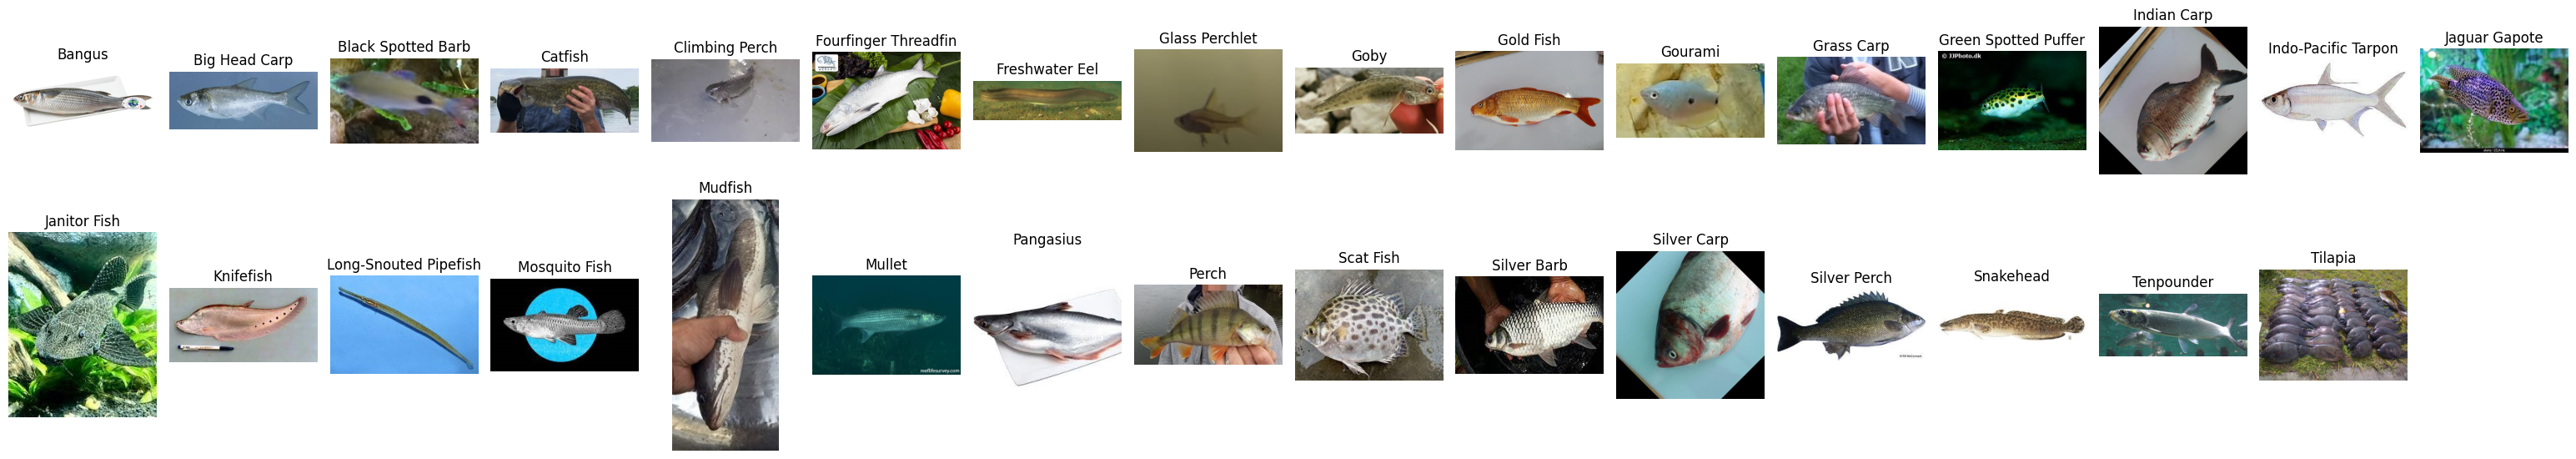

In [13]:
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
class_names = sorted(os.listdir(train_dir))
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
    , '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(31, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

# Task 2: Loading and Preprocessing Image Data

In [15]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

num_classes = len(train_ds.class_names)
class_names = train_ds.class_names

Found 8809 files belonging to 31 classes.
Found 2751 files belonging to 31 classes.


In [16]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),         # Only normalization here

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    batch_size=16,
)

Epoch 1/50
113/276 ━━━━━━━━━━━━━━━━━━━━ 12:20 5s/step - accuracy: 0.1262 - loss: 3.3043